# Gene Regulatory Network Benchmark Evaluation

## Experimental Setup and Data Splitting
**scDGRN** is designed to process time-series gene expression matrices. For baseline methods unable to handle temporal data (e.g., CNNC and GENELINK), we concatenate expression matrices from all time points into a composite input. 

To clarify the usage of regulatory information, we define the **cell-type-specific prior regulatory knowledge** as the set of ground-truth interactions (e.g., from ChIP-seq) available for training. We partition this data into a training set (with 20% reserved for validation) and a non-overlapping held-out test set using a default 2:1 ratio. 

Crucially, the training set serves a dual purpose in our framework:
1. **Structural Prior:** It constructs the initial adjacency matrix for the Graph Attention Network (GAT) to learn gene embeddings.
2. **Supervision Signal:** It provides the positive and negative labels for optimizing model parameters via the loss function.

To ensure a fair comparison, all supervised methods share this identical data split. For unsupervised methods, which do not require prior labels for training, we evaluate their performance on the same held-out test set used for the supervised models.

## 1. AUROC and AUPRC

We use AUROC and AUPRC for overall model evaluation.

* **AUROC (Area Under the Receiver Operating Characteristic curve):** This is the area under the TPR-FPR curve, and reflects the model’s overall classification ability.
* **AUPRC (Area Under the Precision-Recall curve):** This is the area under the Precision-Recall curve. AUPRC is more sensitive to class imbalance, which is highly prevalent in GRN data.

The core components of these metrics are calculated as follows:

$$TPR = recall = \frac{TP}{TP+FN}$$

$$FPR = \frac{FP}{FP+TN}$$

$$precision = \frac{TP}{TP+FP}$$

where **TP** stands for true positive (the number of samples correctly predicted to have a regulatory relationship), **FN** stands for false negative (incorrectly predicted to have no regulatory relationship), **TN** stands for true negative (correctly predicted to have no regulatory relationship), and **FP** represents false positive (no regulatory relationship but incorrectly predicted to have one).

/home/common/llliu/anaconda3/envs/pytorch1/bin/python3.8
current working directory: /home/common/llliu/nar/grn_project/processed_data/TF_group_divid
The current working directory has been changed to: /home/common/llliu/nar/grn_project/processed_data/TF_group_divid
grn_scores_testdata1_TF_specific data:         score  test_data
0    26.083252          1
1     5.773190          1
2    15.851547          1
3     9.123403          1
4     0.612891          1
..         ...        ...
386  15.611251          0
387   0.478125          0
388  27.138623          0
389  33.991568          0
390  14.671648          0

[391 rows x 2 columns]


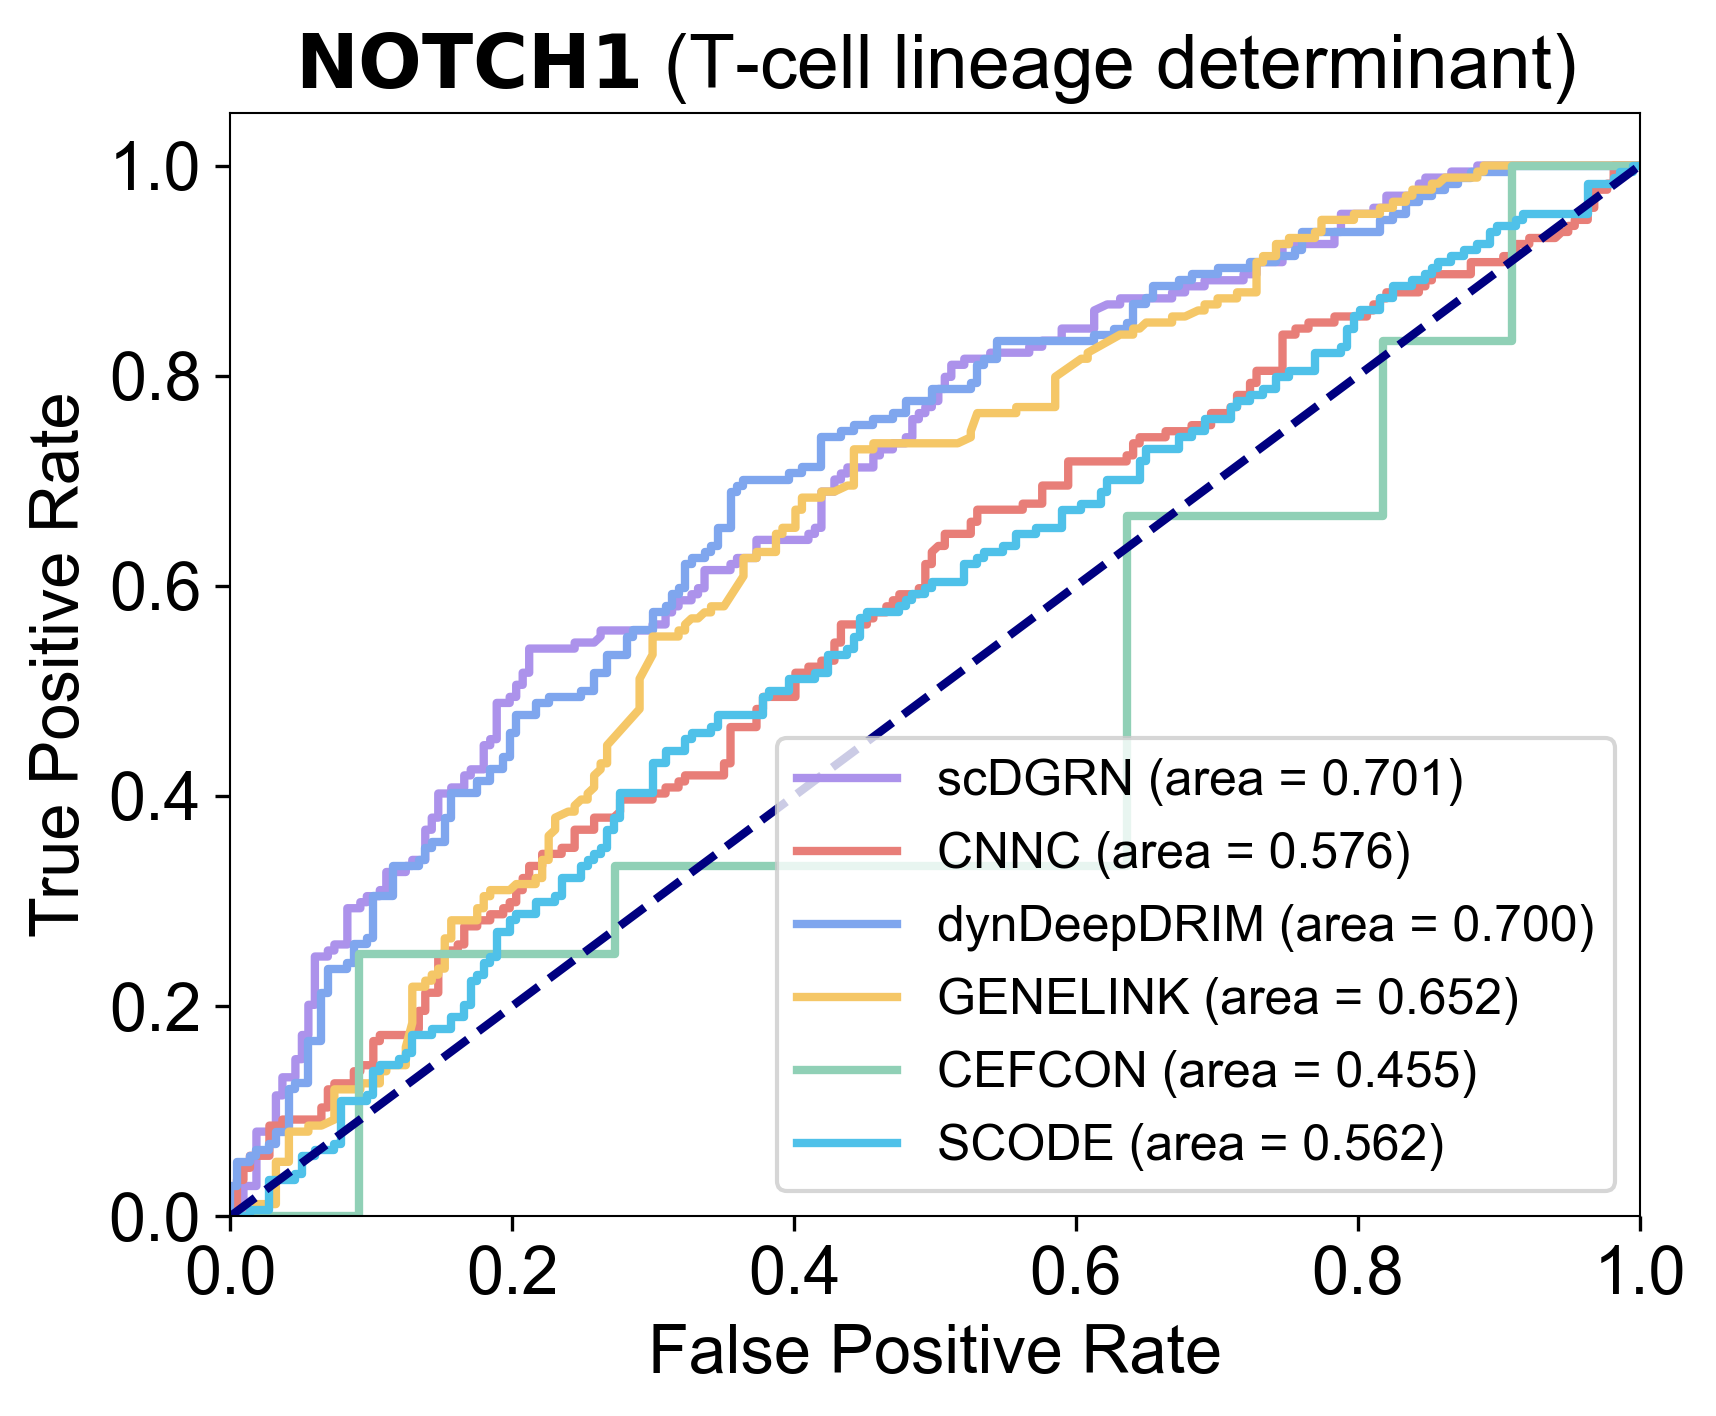

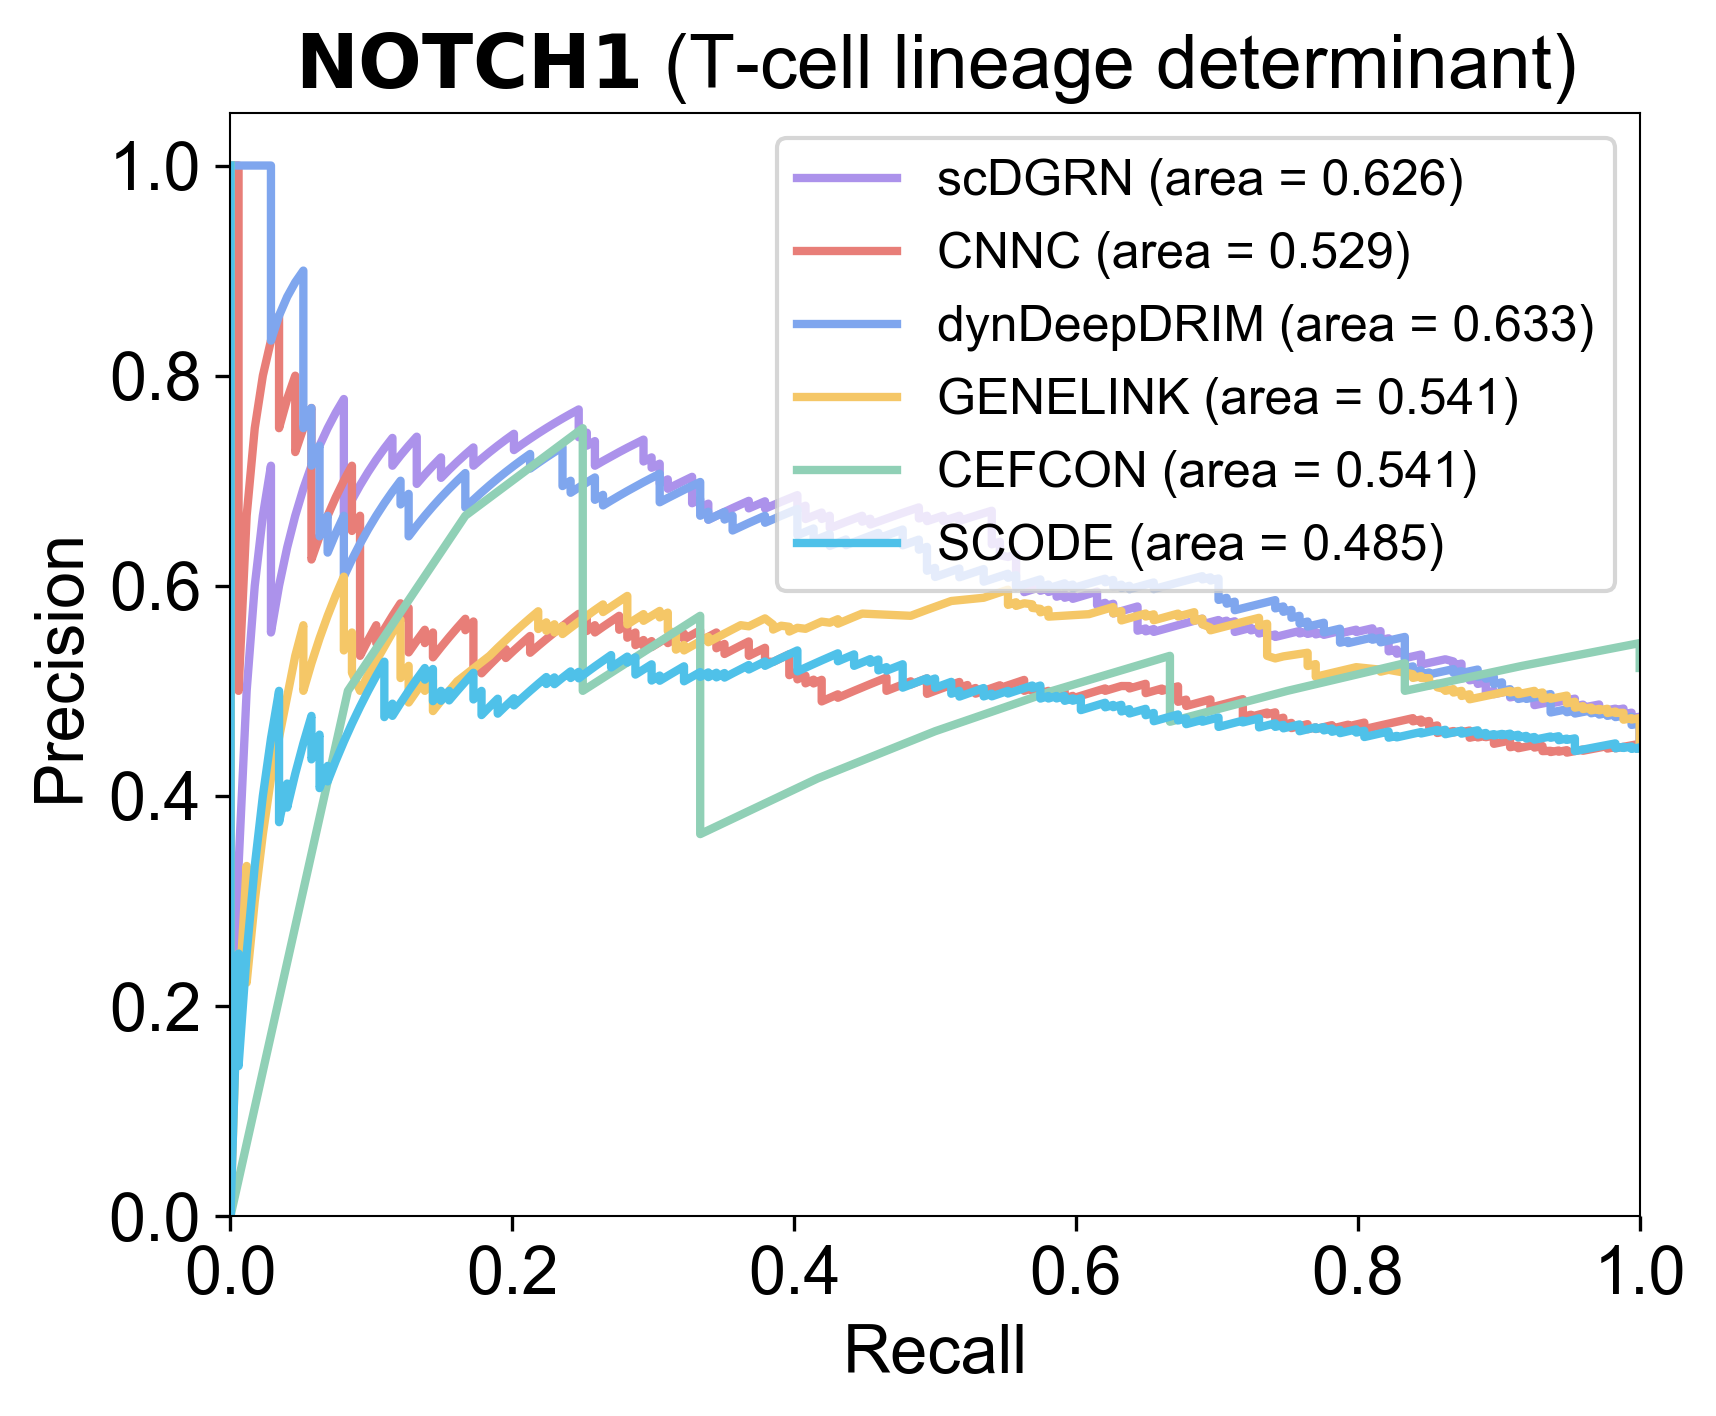

In [7]:
import pandas as pd
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib

rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.linewidth": 0.5,
    "figure.dpi": 300,
    "pdf.fonttype": 42,
    "legend.fontsize": 12,
})

cell_type = 'mHSC-L'
key_TF = 'NOTCH1'

file_paths = [
    '../' + cell_type + '/grn_scores_testdata1_TF_specific_' + key_TF + '.csv',
    '/home/common/llliu/nar/compared_method/CNNC-master/processed_data/' + cell_type +'/grn_scores_testdata1_TF_specific_' + key_TF + '.csv',
    '/home/common/llliu/nar/compared_method/dynDeepDRIM-main/dynDeepDRIM-main/processed_data/' + cell_type + '/grn_scores_testdata1_TF_specific_' + key_TF + '.csv',
    '/home/common/llliu/nar/compared_method/GENELink-main/Demo/' + cell_type + '/c3/grn_scores_testdata1_TF_specific_' + key_TF + '.csv',
    '/home/common/llliu/nar/compared_method/CEFCON-main/output/' + cell_type + '/grn_scores_testdata1_TF_specific_' + key_TF + '.csv',
    '/home/common/llliu/nar/compared_method/SCODE-master/' + cell_type + '/grn_scores_testdata1_TF_specific_' + key_TF + '.csv'
]

roc_data = []
prc_data = []

df = None
for file_path in file_paths:
    df = pd.read_csv(file_path)
    y_true = df['test_data']
    y_scores = df['score']

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    roc_data.append((fpr, tpr, roc_auc))

    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    prc_auc = average_precision_score(y_true, y_scores)
    prc_data.append((recall, precision, prc_auc))

print("grn_scores_testdata1_TF_specific data:{}".format(df))
method = ['scDGRN','CNNC','dynDeepDRIM','GENELINK','CEFCON','SCODE']

colors = [
    "#AC92EB",
    "#E87E78",
    "#7FA6EE",
    "#F5C767",
    "#90D0B6",
    "#4FC1E9"
]

plt.figure(figsize=(6,5))
for i, (fpr, tpr, roc_auc) in enumerate(roc_data):
    plt.plot(fpr, tpr, lw=2, label=f'{method[i]} (area = {roc_auc:.3f})', color=colors[i])

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title(r'$\mathbf{NOTCH1}$ (T-cell lineage determinant)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
for i, (recall, precision, prc_auc) in enumerate(prc_data):
    plt.plot(recall, precision, lw=2, label=f'{method[i]} (area = {prc_auc:.3f})', color=colors[i])

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title(r'$\mathbf{NOTCH1}$ (T-cell lineage determinant)')
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 2. Precision@k

To evaluate the accuracy of the top-ranked predictions, which is crucial for practical biological validation, we utilize **Precision@k**. 

This metric measures the proportion of true regulatory interactions among the top $k$ predicted edges sorted by their confidence scores (where $k$ does not exceed 50% of the total positive samples in the test set). It is defined as:

Precision@k = $\frac{TP_k}{k}$

where $TP_k$ is the number of true positives identified within the top $k$ predictions.

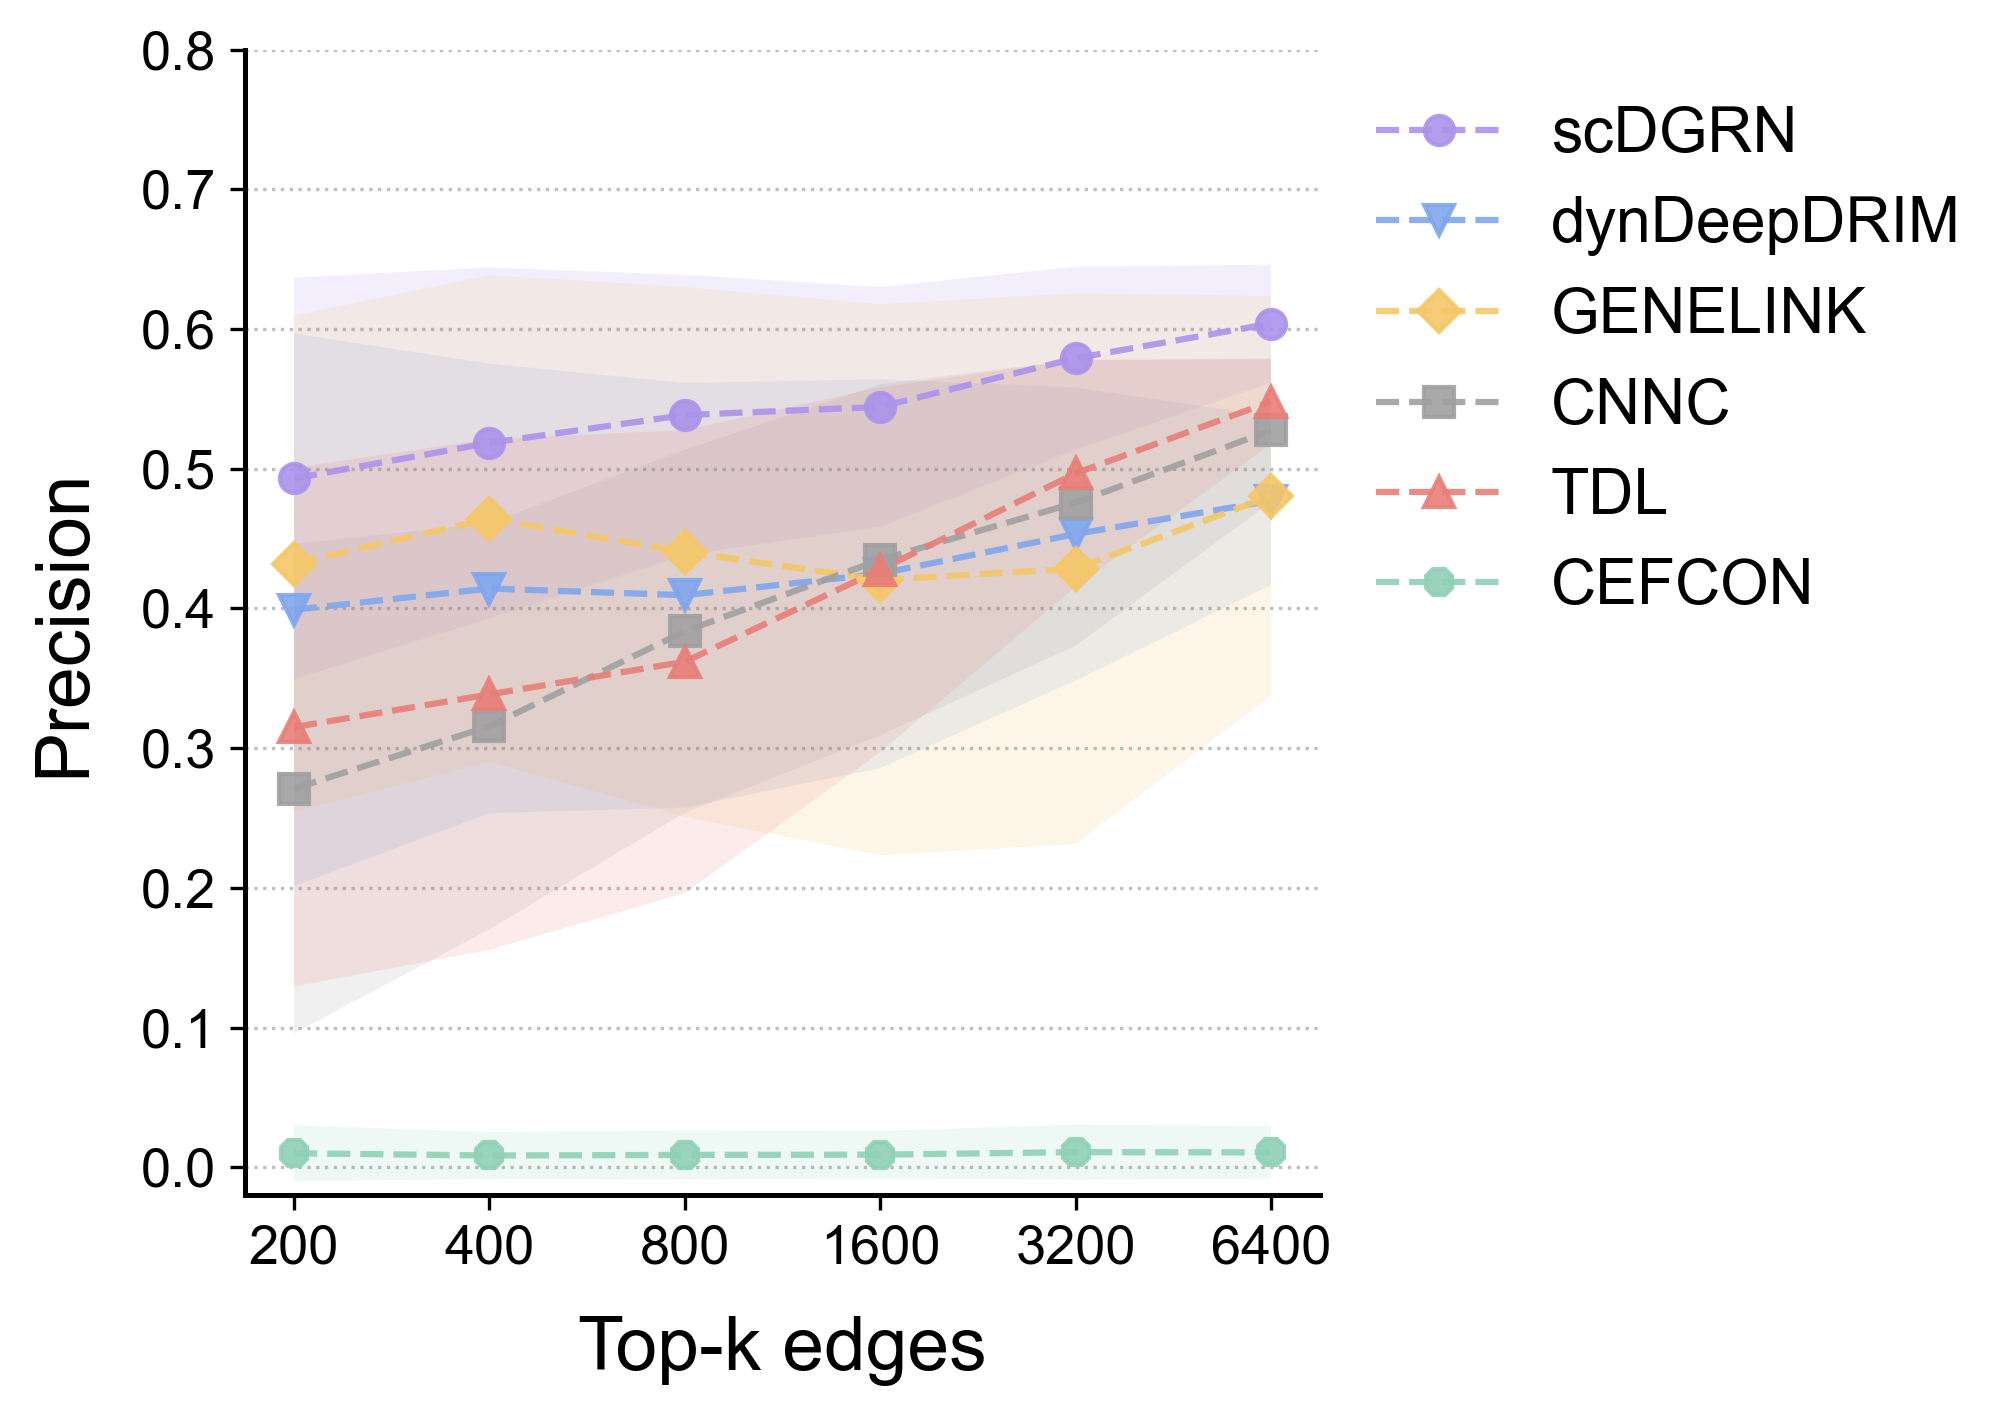

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.legend as mlegend

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

k_values = [200, 400, 800, 1600, 3200, 6400]
k_labels = [str(k) for k in k_values]
raw_data = {
    "CNNC": [[0.215, 0.28, 0.372, 0.466, 0.529, 0.562], [0.05, 0.122, 0.154, 0.193, 0.278, 0.446],
             [0.425, 0.428, 0.481, 0.543, 0.572, 0.597], [0.145, 0.22, 0.379, 0.45, 0.497, 0.527],
             [0.52, 0.528, 0.532, 0.522, 0.502, 0.505]],
    "TDL": [[0.195, 0.182, 0.208, 0.366, 0.461, 0.507], [0.155, 0.145, 0.152, 0.211, 0.36, 0.518],
            [0.615, 0.622, 0.605, 0.595, 0.598, 0.584], [0.16, 0.265, 0.382, 0.496, 0.542, 0.573],
            [0.45, 0.478, 0.462, 0.47, 0.522, 0.558]],
    "GENELINK": [[0.555, 0.552, 0.534, 0.546, 0.555, 0.548], [0.665, 0.672, 0.664, 0.632, 0.657, 0.695],
                 [0.355, 0.442, 0.351, 0.277, 0.182, 0.293], [0.44, 0.505, 0.535, 0.541, 0.546, 0.511],
                 [0.145, 0.15, 0.118, 0.106, 0.202, 0.355]],
    "dynDeepDRIM": [[0.265, 0.298, 0.255, 0.258, 0.317, 0.398], [0.1, 0.175, 0.215, 0.265, 0.342, 0.421],
                    [0.65, 0.62, 0.605, 0.602, 0.584, 0.488], [0.425, 0.438, 0.442, 0.478, 0.503, 0.516],
                    [0.555, 0.54, 0.53, 0.521, 0.52, 0.562]],
    "scDGRN": [[0.655, 0.672, 0.664, 0.654, 0.66, 0.653], [0.655, 0.608, 0.575, 0.521, 0.49, 0.542],
               [0.485, 0.572, 0.595, 0.609, 0.63, 0.635], [0.355, 0.358, 0.374, 0.403, 0.516, 0.567],
               [0.315, 0.382, 0.484, 0.534, 0.599, 0.622]],
    "CEFCON": [[0.0, 0.0, 0.0, 0.002, 0.004, 0.005], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
               [0.05, 0.042, 0.044, 0.043, 0.05, 0.048], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
               [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
}

for key in raw_data:
    if len(raw_data[key]) == 1 and isinstance(raw_data[key][0], list) and isinstance(raw_data[key][0][0], list):
        raw_data[key] = raw_data[key][0]

processed_data = {}
for method, runs in raw_data.items():
    runs_np = np.array(runs)
    mean = np.mean(runs_np, axis=0)
    std = np.std(runs_np, axis=0)
    processed_data[method] = {"mean": mean, "std": std}

colors = {
    "scDGRN": "#AC92EB",
    "dynDeepDRIM": "#7FA6EE",
    "CNNC": "#A0A0A0",
    "TDL": "#E87E78",
    "GENELINK": "#F5C767",
    "CEFCON": "#90D0B6"
}

markers = {
    "scDGRN": "o", "CNNC": "s", "TDL": "^", "GENELINK": "D", "dynDeepDRIM": "v",
    "CEFCON": "8"
}

plot_order = [
    "scDGRN", "dynDeepDRIM", "GENELINK", "CNNC", "TDL", "CEFCON"
]

fig, ax = plt.subplots(figsize=(7, 5))

x_indices = np.arange(len(k_values))

for method in plot_order:
    if method not in processed_data:
        continue

    data = processed_data[method]
    y_mean = data["mean"]
    y_std = data["std"]

    ax.plot(x_indices, y_mean,
            color=colors[method],
            marker=markers[method],
            markersize=7,
            linestyle='--',
            linewidth=1.5,
            alpha=0.9,
            label=method)

    ax.fill_between(x_indices, y_mean - y_std, y_mean + y_std,
                    color=colors[method],
                    alpha=0.15,
                    edgecolor=None)

ax.set_xticks(x_indices)
ax.set_xticklabels(k_labels, fontsize=13)
ax.set_xlabel("Top-k edges", fontsize=18, labelpad=10)

ax.set_ylabel("Precision", fontsize=18, labelpad=10)
ax.tick_params(axis='y', labelsize=13)
ax.set_ylim(-0.02, 0.8)

ax.grid(True, which='major', axis='y', linestyle=':', color='gray', alpha=0.5)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.legend(loc='best', frameon=False, fontsize=15, bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()

## 3. Calibration Curves

Furthermore, we generate **Calibration curves** to assess the reliability of the predicted probabilities, ensuring that the confidence scores mathematically align with the actual likelihood of interaction.

To construct the curve, the predicted probabilities are partitioned into $M$ bins. For each bin, the mean predicted probability is plotted against the observed fraction of positive samples (true regulatory links). A perfectly calibrated model results in a curve that strictly follows the diagonal line ($y=x$), indicating that the predicted probabilities accurately reflect the true correctness rates.

grn_scores_testdata:          score  test_data
0      0.701267          1
1      0.729633          1
2      0.775095          1
3      0.702606          1
4      0.756487          1
...         ...        ...
13335  0.569446          0
13336  0.637512          0
13337  0.673065          0
13338  0.622643          0
13339  0.670529          0

[13340 rows x 2 columns]
[1.         1.         0.99999999 ... 0.78402808 0.99979257 0.99999996]
[0.72031092 0.72343329 0.72365511 ... 0.73208717 0.71967632 0.71728672]


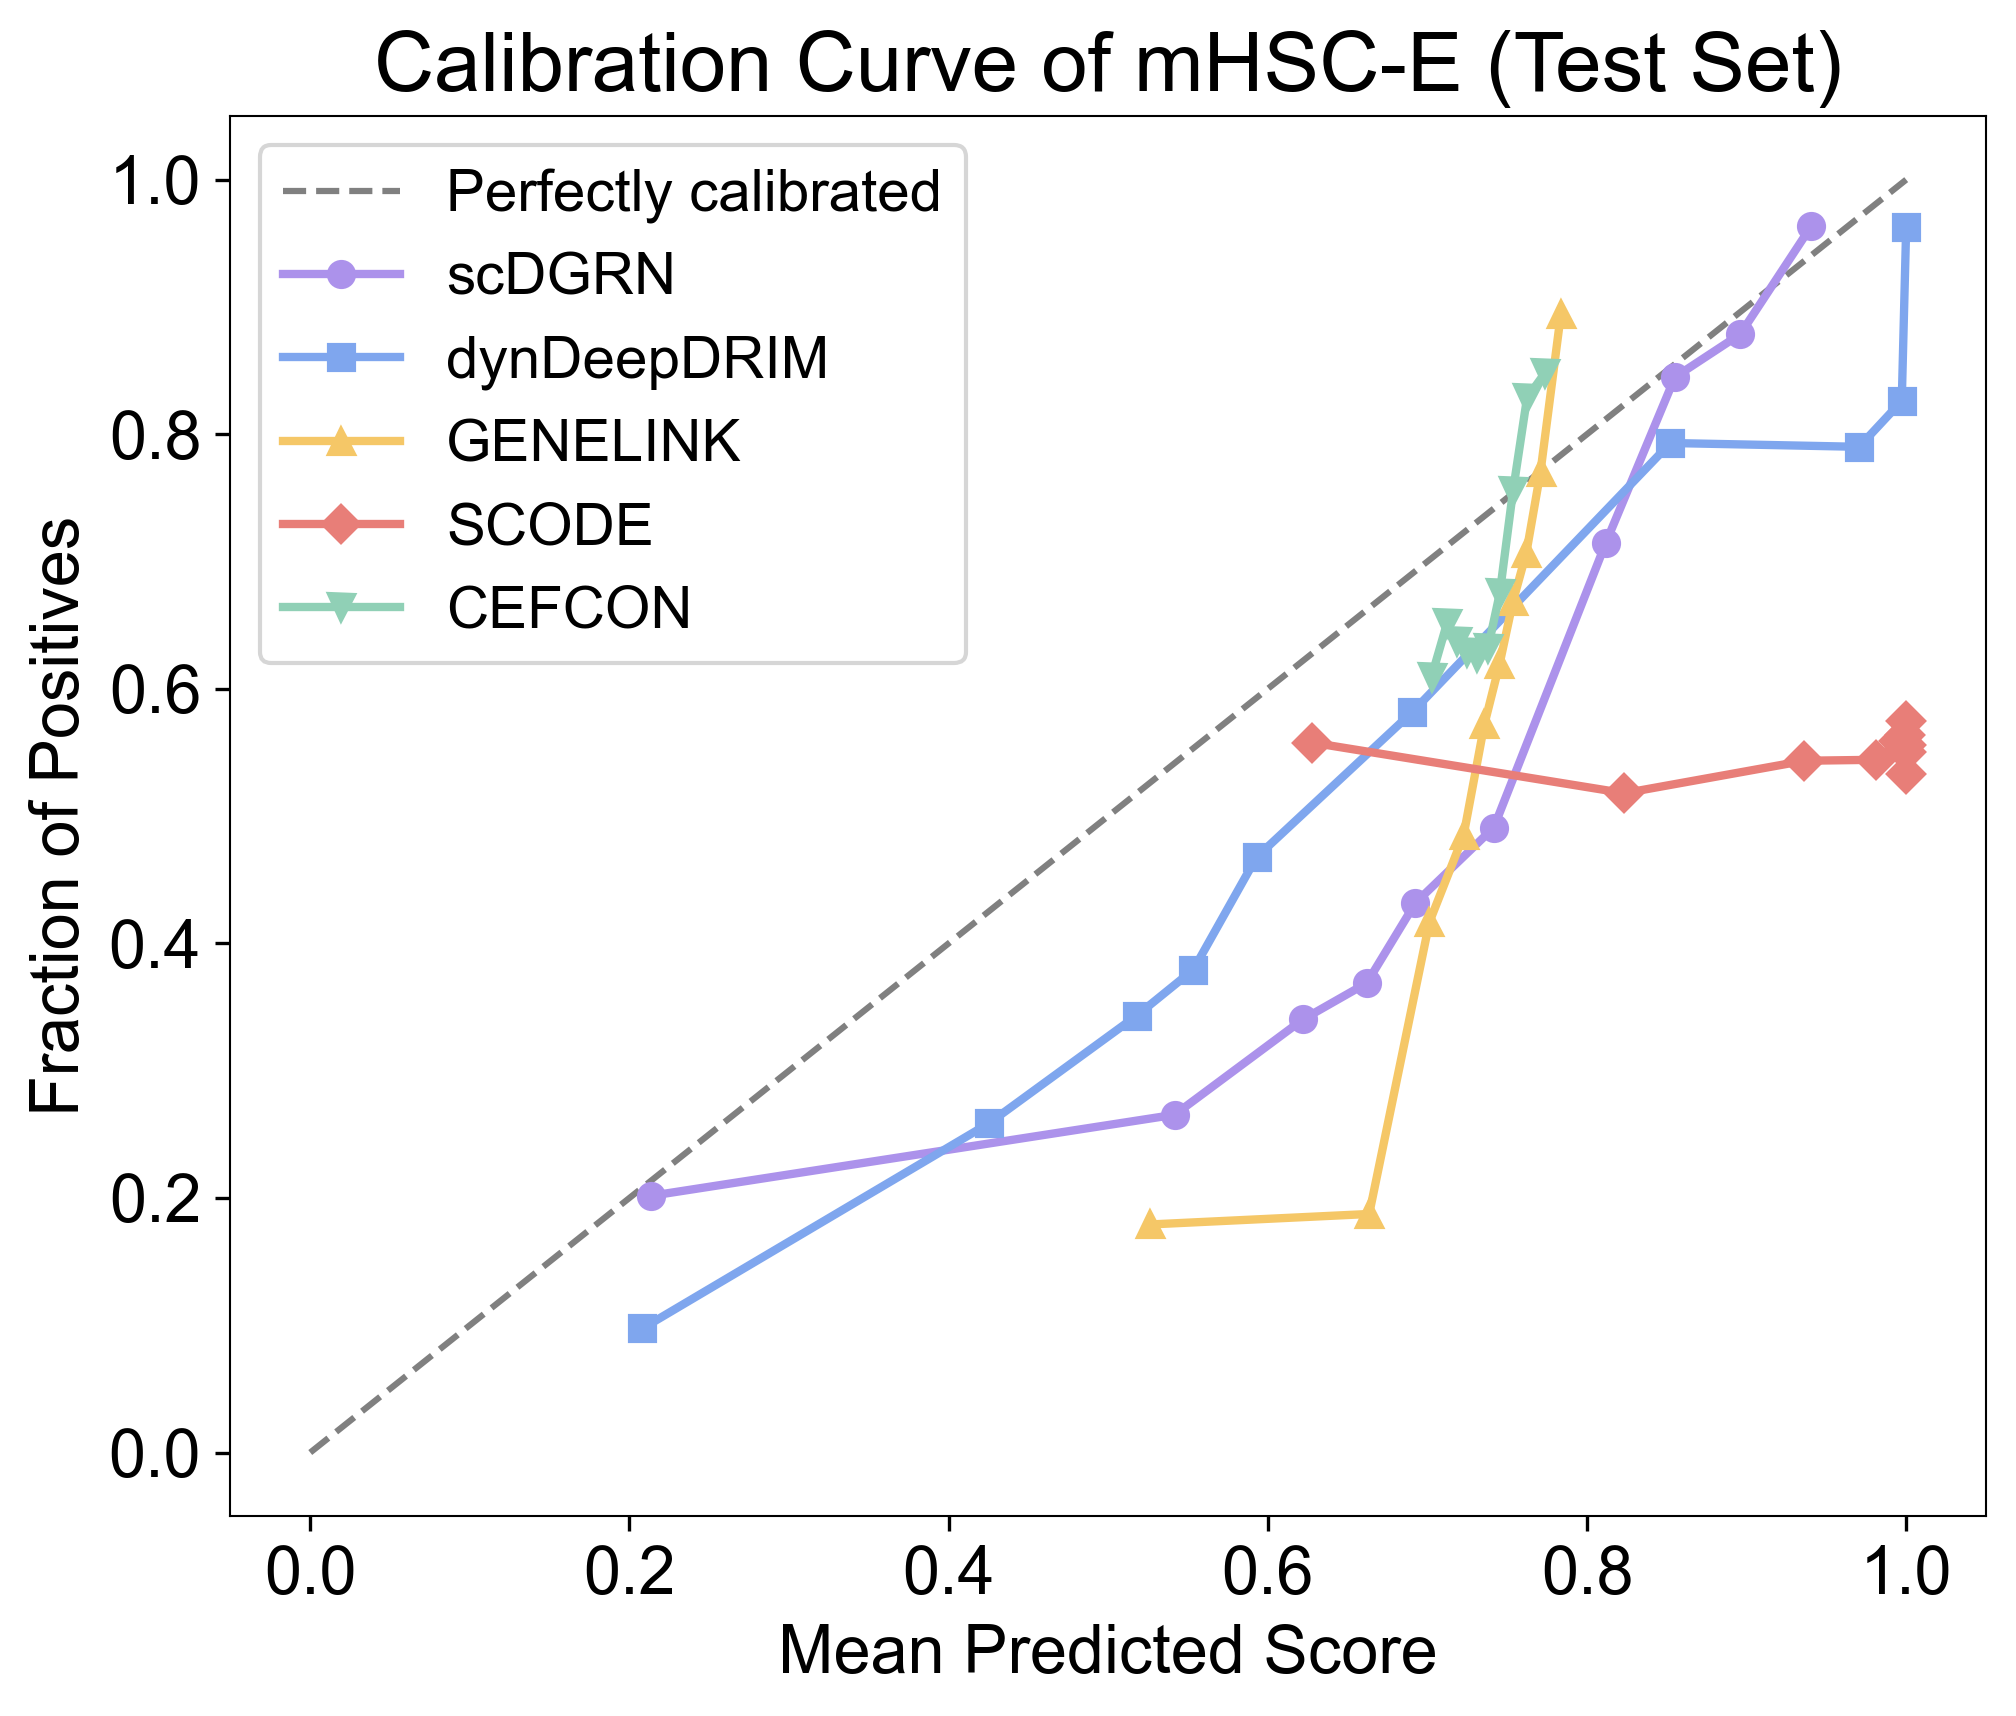

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
from matplotlib import rcParams

rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.linewidth": 0.5,
    "figure.dpi": 300,
    "pdf.fonttype": 42,
    "legend.fontsize": 14,
})

cell_type = 'mHSC-E'
divid_type = '_raw'
y_true_list = []
y_score_list = []

df1 = pd.read_csv('./processed_data/' + cell_type + '/grn_scores_testdata1' + divid_type + '.csv')
y_true1 = df1["test_data"]
y_score1 = df1["score"]
y_true_list.append(y_true1)
y_score_list.append(y_score1)
print("grn_scores_testdata:{}".format(df1))

df2 = pd.read_csv('./processed_data/' + cell_type + '/grn_scores_testdata1' + divid_type + '_dynDRIM.csv')
y_true2 = df2["test_data"]
y_score2 = df2["score"]
y_true_list.append(y_true2)
y_score_list.append(y_score2)

df3 = pd.read_csv('./processed_data/' + cell_type + '/grn_scores_testdata1' + divid_type + '_GENELINK.csv')
y_true3 = df3["test_data"]
y_score3 = df3["score"]
y_true_list.append(y_true3)
y_score_list.append(y_score3)

df4 = pd.read_csv('./processed_data/' + cell_type + '/grn_scores_testdata1' + divid_type + '_SCODE.csv')
y_true4 = df4["test_data"]
y_score4 = df4["score"]
y_true_list.append(y_true4)
y_score_list.append(y_score4)

df5 = pd.read_csv('./processed_data/' + cell_type + '/grn_scores_testdata1' + divid_type + '_CEFCON.csv')
y_true6 = df5["test_data"]
y_score6 = df5["score"]
y_true_list.append(y_true6)
y_score_list.append(y_score6)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

count = 0
for y_score in y_score_list:
    if max(y_score.values.tolist()) > 1 or min(y_score.values.tolist()) < 0:
        y_score = np.array(y_score.values.tolist())
        y_score = sigmoid(y_score)
        print(y_score)
        y_score_list[count] = y_score
    count = count +1

method = ['scDGRN','dynDeepDRIM','GENELINK','SCODE','CEFCON']

colors = [
    "#AC92EB",
    "#7FA6EE",
    "#F5C767",
    "#E87E78",
    "#90D0B6",
]

markers = [
    'o',
    's',
    '^',
    'D',
    'v',
    'p'
]

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Perfectly calibrated")
for i in range(len(y_true_list)):
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true_list[i], y_score_list[i], n_bins=10, strategy="quantile"
    )

    plt.plot(mean_predicted_value, fraction_of_positives, marker=markers[i % len(markers)],
             label=method[i], color=colors[i % len(colors)], linewidth=2)

plt.xlabel("Mean Predicted Score")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve of mHSC-E (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()